### PART 1 - Initial Setup

# imports

In [25]:
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


### 1. Load the Dataset

In [26]:
try:
    df = pd.read_csv('traffic_sample.csv', encoding='utf-8')
except FileNotFoundError:
    raise FileNotFoundError("Ensure 'traffic_sample.csv' is in the current working directory. Run 'import os; print(os.getcwd())' to check.")


### 2. Display First Rows

In [27]:
df.head()

,src_ip,dest_ip,protocol,src_port,dest_port,flow_duration,bytes,packets,timestamp,label
0,103.179.92.15,126.239.53.162,TCP,19719,43828,2.318,7919,164,2025-11-01 00:00:00,0
1,107.71.188.21,211.144.132.89,ICMP,2253,22895,0.913,8472,16,2025-11-01 00:01:00,0
2,103.121.210.215,146.251.182.53,ICMP,2554,33976,1.601,8596,193,2025-11-01 00:02:00,0
3,75.202.87.117,50.71.218.207,ICMP,46609,24993,1.365,1248,67,2025-11-01 00:03:00,0
4,100.103.151.131,173.140.15.214,ICMP,43371,43737,3.453,4160,167,2025-11-01 00:04:00,0


### 3. Display Dataset Dimensions

In [28]:
rows, cols = df.shape
print(f"Dataset dimensions: {rows} rows, {cols} columns")

Dataset dimensions: 5000 rows, 10 columns


# PART 2 - Data Preprocessing & Cleaning

### 2.1 Handling Missing Values

In [29]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percent
}).sort_values(by='Missing Count', ascending=False)

print("Missing values summary:")
display(missing_df)



Missing values summary:


,Missing Count,Missing Percent
src_ip,0,0.0
dest_ip,0,0.0
protocol,0,0.0
src_port,0,0.0
dest_port,0,0.0
flow_duration,0,0.0
bytes,0,0.0
packets,0,0.0
timestamp,0,0.0
label,0,0.0


In [30]:
high_missing = missing_df[missing_df['Missing Percent'] > 40]
if not high_missing.empty:
    print("Warning: High missing columns:", high_missing.index.tolist())

### Decide Deletion or Imputation

In [31]:

numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in df.columns:
    if missing_df.loc[col, 'Missing Percent'] > 40:
        df.drop(col, axis=1, inplace=True)
        print(f"Dropped '{col}' (high missing).")
    elif missing_counts[col] > 0:
        if col in numerical_cols:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Imputed '{col}' with median: {median_val}")
        elif col in categorical_cols:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed '{col}' with mode: {mode_val}")

if missing_df['Missing Percent'].mean() < 5:
    df.dropna(inplace=True)
    print("Dropped rows with missing (low overall).")

print("Remaining missing:", df.isnull().sum().sum())

Dropped rows with missing (low overall).
Remaining missing: 0


### 2.2 Handling Outliers

In [32]:


for col in numerical_cols:
    if len(df[col].dropna()) > 3:
        stat, p = stats.shapiro(df[col].dropna())
        print(f"'{col}' normality p-value: {p:.4f} ({'normal' if p > 0.05 else 'non-normal'})")

method = 'IQR'  # Default; change to 'Z-score' if most columns are normal

'src_port' normality p-value: 0.0000 (non-normal)
'dest_port' normality p-value: 0.0000 (non-normal)
'flow_duration' normality p-value: 0.0000 (non-normal)
'bytes' normality p-value: 0.0000 (non-normal)
'packets' normality p-value: 0.0000 (non-normal)
'label' normality p-value: 0.0000 (non-normal)


### Plot and Identify Outliers

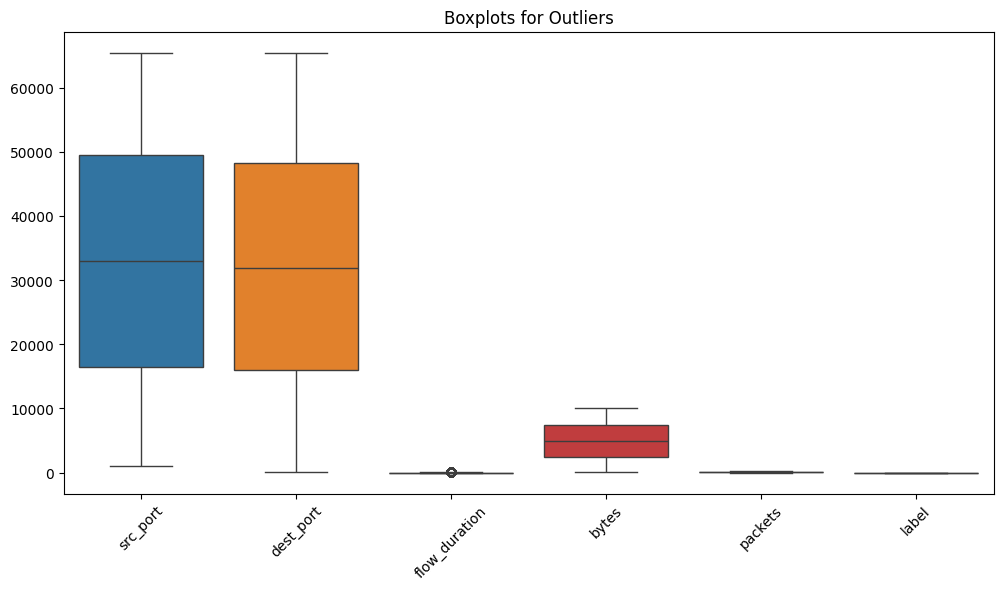

Capped outliers in 'src_port'.


"Outliers in 'src_port': 0"

Capped outliers in 'dest_port'.


"Outliers in 'dest_port': 0"

Capped outliers in 'flow_duration'.


...

"Outliers in 'bytes': 0"

Capped outliers in 'packets'.


"Outliers in 'packets': 0"

Capped outliers in 'label'.


"Outliers in 'label': 0"

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplots for Outliers')
plt.xticks(rotation=45)
plt.show()

outliers_dict = {}
for col in numerical_cols:
    if method == 'IQR':
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        df[col] = np.clip(df[col], lower, upper)
        print(f"Capped outliers in '{col}'.")
    elif method == 'Z-score':
        z = np.abs(stats.zscore(df[col].dropna()))
        outliers = df[(z > 3).reindex(df.index, fill_value=False)]
    outliers_dict[col] = len(outliers)
    display(f"Outliers in '{col}': {outliers_dict[col]}")

# PART 3 - Data Integration

### 3.1 Vertical Integration

In [38]:
try:
    df1 = pd.read_csv('traffic_day1.csv', encoding='utf-8')
    df2 = pd.read_csv('traffic_day2.csv', encoding='utf-8')
except UnicodeDecodeError:
    df1 = pd.read_csv('traffic_day1.csv', encoding='latin1')
    df2 = pd.read_csv('traffic_day2.csv', encoding='latin1')

if not df1.columns.equals(df2.columns):
    raise ValueError("Schemas mismatch.")

for col in df1.columns:
    if df1[col].dtype != df2[col].dtype:
        df2[col] = df2[col].astype(df1[col].dtype)

integrated_df = pd.concat([df1, df2], ignore_index=True)

pre_dup = integrated_df.shape[0]
integrated_df.drop_duplicates(inplace=True)
print(f"Removed {pre_dup - integrated_df.shape[0]} duplicates.")

print("Integrated dimensions:", integrated_df.shape)
display(integrated_df.head())

Removed 0 duplicates.
Integrated dimensions: (20, 5)


,flow_duration,bytes,packets,protocol,label
0,1.2,200,5,6,normal
1,3.4,540,12,17,normal
2,0.0,120,3,6,normal
3,10.5,8000,60,1,attack
4,2.2,230,8,17,normal


# Data Reduction

In [35]:

X = integrated_df.select_dtypes(include=[np.number]).dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_scaled)
reduced_df = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(X_reduced.shape[1])])

print(f"Reduced from {X.shape[1]} to {reduced_df.shape[1]} components.")
print("Explained variance:", pca.explained_variance_ratio_)

Reduced from 4 to 2 components.
Explained variance: [0.70488943 0.25124369]


### Data Discretization

In [40]:
numerical_cols = integrated_df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if integrated_df[col].nunique() > 1:
        integrated_df[f'{col}_binned'] = pd.qcut(integrated_df[col], q=5, labels=False, duplicates='drop')
        display(f"Discretized '{col}' into {integrated_df[f'{col}_binned'].nunique()} bins.")
        display(integrated_df[f'{col}_binned'].value_counts())

"Discretized 'flow_duration' into 5 bins."

flow_duration_binned
1    4
2    4
0    4
4    4
3    4
Name: count, dtype: int64

"Discretized 'bytes' into 5 bins."

bytes_binned
1    4
2    4
3    4
4    4
0    4
Name: count, dtype: int64

"Discretized 'packets' into 5 bins."

...

bytes_binned_binned
1    4
2    4
3    4
4    4
0    4
Name: count, dtype: int64

"Discretized 'packets_binned' into 5 bins."

packets_binned_binned
1    4
2    4
3    4
4    4
0    4
Name: count, dtype: int64

"Discretized 'protocol_binned' into 1 bins."

protocol_binned_binned
0    20
Name: count, dtype: int64

In [37]:
integrated_df.to_csv('processed_traffic.csv', index=False)
print("Processed dataset saved as 'processed_traffic.csv'.")

Processed dataset saved as 'processed_traffic.csv'.


In [41]:
meta = pd.read_csv('ip_metadata.csv')

In [43]:
df.merge(meta, on='src_ip', how='left')

,src_ip,dest_ip,protocol,src_port,dest_port,flow_duration,bytes,packets,timestamp,label,region,isp,is_internal
0,103.179.92.15,126.239.53.162,TCP,19719,43828,2.318,7919,164,2025-11-01 00:00:00,0,NaN,NaN,NaN
1,107.71.188.21,211.144.132.89,ICMP,2253,22895,0.913,8472,16,2025-11-01 00:01:00,0,NaN,NaN,NaN
2,103.121.210.215,146.251.182.53,ICMP,2554,33976,1.601,8596,193,2025-11-01 00:02:00,0,NaN,NaN,NaN
3,75.202.87.117,50.71.218.207,ICMP,46609,24993,1.365,1248,67,2025-11-01 00:03:00,0,NaN,NaN,NaN
4,100.103.151.131,173.140.15.214,ICMP,43371,43737,3.453,4160,167,2025-11-01 00:04:00,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,125.162.38.220,212.65.25.126,ICMP,7837,10115,3.676,7066,61,2025-11-04 11:15:00,0,NaN,NaN,NaN
4996,51.3.120.80,57.254.227.25,TCP,27374,646,1.050,8181,93,2025-11-04 11:16:00,0,NaN,NaN,NaN
4997,77.211.178.133,30.209.134.27,TCP,23049,5885,1.907,7219,182,2025-11-04 11:17:00,1,NaN,NaN,NaN
4998,55.228.19.152,139.100.135.11,TCP,30016,23053,0.484,5837,186,2025-11-04 11:18:00,0,NaN,NaN,NaN


In [ ]:
df = df.merge(meta, on='src_ip', how='left')